![earthkit-hydro-logo](https://github.com/ecmwf/logos/raw/refs/heads/main/logos/earthkit/earthkit-hydro-light.svg)

# Earthkit-hydro: Computing Catchment Statistics

Tnis notebook will show a simple example of computing catchment statistics.

In [1]:
import earthkit.plots as ekp
import earthkit.hydro as ekh
import earthkit.data as ekd

In [2]:
network = ekh.river_network.load("efas", "5")

da = ekd.from_source(
    "sample",
    "R06a.nc",
).to_xarray()["R06a"].isel(time=0).load() # making sure it's not chunked in space

River network not found in cache (/etc/ecmwf/ssd/ssd1/jupyterhub/macw-jupyterhub/tmpdirs/macw.39412013/tmp3tw77g5a_earthkit_hydro/1.2_0dc8123bbf944ff1cb86f41bc7506e891baaa990666d836fc0cf2edd503916db.joblib).
River network loaded, saving to cache (/etc/ecmwf/ssd/ssd1/jupyterhub/macw-jupyterhub/tmpdirs/macw.39412013/tmp3tw77g5a_earthkit_hydro/1.2_0dc8123bbf944ff1cb86f41bc7506e891baaa990666d836fc0cf2edd503916db.joblib).


In practice, computing full-field accumulations is often not required and users may wish to calculate only for certain areas of interest. In hydrology, the canonical unit over which to calculate is typically a catchment.

In earthkit-hydro, catchments are specified by specifying the location of the most downstream cell.

As an example, we specify two disjoint catchments in this notebook.

In [3]:
locations={
    "Reading": (50.736364, 7.10807),
    "Bonn": (51.461325, -0.967884)
}

To begin, we visualise the catchments to confirm we have correctly specified the right location on the river network.

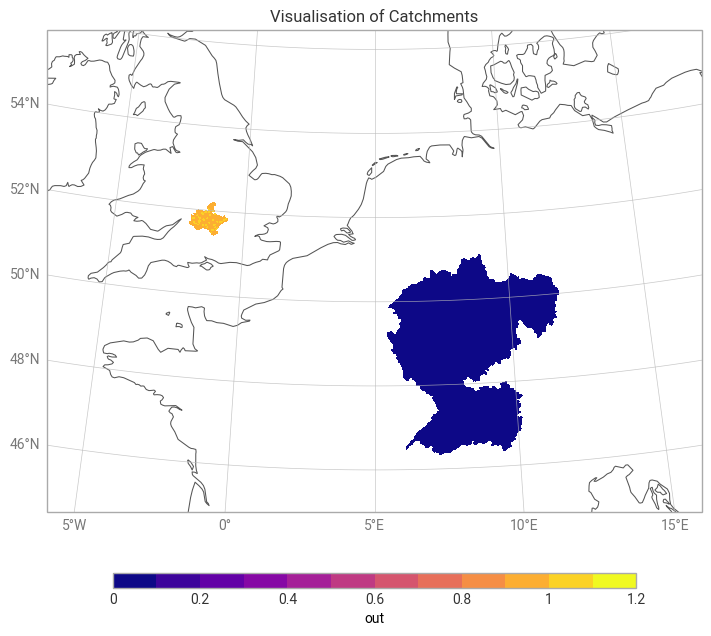

In [6]:
find_catchments = ekh.catchments.find(network, locations)

chart = ekp.Map(domain=[-6, 16, 45, 56])
chart.quickplot(find_catchments)
chart.legend(label="{variable_name}")
chart.title("Visualisation of Catchments")
chart.coastlines()
chart.gridlines()
chart.show()

We can then easily compute catchment statistics over these areas. Many metrics are available. As an example, we compute catchment averages for both gauge locations.

In [5]:
ekh.catchments.mean(network, da, locations)

<xarray.DataArray 'R06a' (node_index: 2)> Size: 16B
array([1.60711125, 1.18422593])
Coordinates:
  * node_index  (node_index) int64 16B 2739356 2603166
    lat         (node_index) float64 16B 50.74 51.46
    lon         (node_index) float64 16B 7.108 -0.975
    name        (node_index) <U7 56B 'gauge_1' 'gauge_2'
    time        datetime64[ns] 8B 2024-11-14T06:00:00
Attributes:
    units:          mm
    standard_name:  precipitation
    long_name:      precipitation